# Laboratorio 3 — Deep Learning: Reconocimiento de Lenguaje de Señas (ASL)
## Entrega final: Modelos, comparación, augmentation y accesibilidad

CC3084 – Data Science, Semestre II 2026, UVG.

Continúa sobre lo hecho en el avance (`avance_eda_preprocesamiento.ipynb`: EDA, preprocesamiento,
split train/val/test 70/15/15 estratificado, imágenes 64x64 RGB normalizadas en `[0,1]`). Aquí se
cubren los ejercicios 4-7, 9 y 10 del enunciado: modelos de deep learning (CNN), red
fully-connected, modelo clásico, image augmentation, y reflexión de accesibilidad.

El ejercicio 8 (pruebas con fotos de señas hechas por los integrantes del grupo) se resuelve en un
notebook aparte (`ejercicio8_fotos_propias.ipynb`) una vez que se cuenta con esas fotos reales.

In [1]:
import json
import time
from pathlib import Path

import cv2
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import tensorflow as tf
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score

sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 110

SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

PROCESSED_DIR = Path("../../data/processed/asl_alphabet")
MODELS_DIR = Path("../models")
MODELS_DIR.mkdir(exist_ok=True)
FIGURAS_DIR = Path("../../reports/figuras")

with open(PROCESSED_DIR / "clases.json") as f:
    clase_a_indice = json.load(f)
indice_a_clase = {v: k for k, v in clase_a_indice.items()}
CLASES = [indice_a_clase[i] for i in range(len(indice_a_clase))]
N_CLASES = len(CLASES)
print(f"{N_CLASES} clases: {CLASES}")

X_train = np.load(PROCESSED_DIR / "X_train.npy")
y_train = np.load(PROCESSED_DIR / "y_train.npy")
X_val = np.load(PROCESSED_DIR / "X_val.npy")
y_val = np.load(PROCESSED_DIR / "y_val.npy")
X_test = np.load(PROCESSED_DIR / "X_test.npy")
y_test = np.load(PROCESSED_DIR / "y_test.npy")

print(f"train {X_train.shape}, val {X_val.shape}, test {X_test.shape}")

29 clases: ['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J', 'K', 'L', 'M', 'N', 'O', 'P', 'Q', 'R', 'S', 'T', 'U', 'V', 'W', 'X', 'Y', 'Z', 'del', 'nothing', 'space']


train (12180, 64, 64, 3), val (2610, 64, 64, 3), test (2610, 64, 64, 3)


### Metodología de evaluación

Todos los modelos se entrenan sobre el mismo `train`, se seleccionan (hiperparámetros / early
stopping) con `val`, y se reportan al final sobre `test` (nunca visto durante el ajuste). Se reporta
**accuracy** y **F1 macro** — F1 macro pondera igual a cada una de las 29 clases, relevante aunque el
dataset esté balanceado porque nos interesa el desempeño en los grupos de letras confundibles
(M/N/S, U/V/R, etc.) identificados en el EDA, no solo el promedio general.

In [2]:
resultados = []  # se va llenando: dict(modelo, categoria, val_acc, val_f1, test_acc, test_f1, ...)


def evaluar(nombre, categoria, modelo_predict_fn, guardar=True):
    t0 = time.time()
    val_pred = modelo_predict_fn(X_val)
    test_pred = modelo_predict_fn(X_test)
    fila = {
        "modelo": nombre,
        "categoria": categoria,
        "val_acc": accuracy_score(y_val, val_pred),
        "val_f1_macro": f1_score(y_val, val_pred, average="macro"),
        "test_acc": accuracy_score(y_test, test_pred),
        "test_f1_macro": f1_score(y_test, test_pred, average="macro"),
        "seg_evaluar": time.time() - t0,
    }
    if guardar:
        resultados.append(fila)
    return fila, test_pred

## Ejercicio 4: Modelos de Deep Learning (CNN)

Se entrenan **2 arquitecturas CNN**, cada una con **2 variantes de hiperparámetros** (4 corridas en
total), para cumplir con "probar varios modelos variando los parámetros hasta encontrar el mejor".

In [3]:
def construir_cnn_base(dropout=0.0, lr=1e-3):
    modelo = tf.keras.Sequential([
        tf.keras.layers.Input((64, 64, 3)),
        tf.keras.layers.Conv2D(32, 3, activation="relu", padding="same"),
        tf.keras.layers.MaxPooling2D(),
        tf.keras.layers.Conv2D(64, 3, activation="relu", padding="same"),
        tf.keras.layers.MaxPooling2D(),
        tf.keras.layers.Conv2D(128, 3, activation="relu", padding="same"),
        tf.keras.layers.MaxPooling2D(),
        tf.keras.layers.GlobalAveragePooling2D(),
        tf.keras.layers.Dropout(dropout),
        tf.keras.layers.Dense(N_CLASES, activation="softmax"),
    ])
    modelo.compile(optimizer=tf.keras.optimizers.Adam(lr),
                    loss="sparse_categorical_crossentropy", metrics=["accuracy"])
    return modelo


def construir_cnn_profunda(dropout=0.3, lr=2e-4):
    # BatchNormalization con momentum=0.9 (en vez del 0.99 por defecto) para que las
    # estadísticas móviles converjan en pocas épocas; con lr=1e-3 y momentum=0.99 se observó
    # que el train accuracy subía normalmente pero val_accuracy quedaba en nivel de azar y
    # val_loss se disparaba (BatchNorm con estadísticas de inferencia aún sin estabilizar).
    bn = lambda: tf.keras.layers.BatchNormalization(momentum=0.9)
    modelo = tf.keras.Sequential([
        tf.keras.layers.Input((64, 64, 3)),
        tf.keras.layers.Conv2D(32, 3, activation="relu", padding="same"),
        bn(),
        tf.keras.layers.Conv2D(32, 3, activation="relu", padding="same"),
        bn(),
        tf.keras.layers.MaxPooling2D(),
        tf.keras.layers.Dropout(dropout),

        tf.keras.layers.Conv2D(64, 3, activation="relu", padding="same"),
        bn(),
        tf.keras.layers.Conv2D(64, 3, activation="relu", padding="same"),
        bn(),
        tf.keras.layers.MaxPooling2D(),
        tf.keras.layers.Dropout(dropout),

        tf.keras.layers.Conv2D(128, 3, activation="relu", padding="same"),
        bn(),
        tf.keras.layers.MaxPooling2D(),
        tf.keras.layers.Dropout(dropout),

        tf.keras.layers.GlobalAveragePooling2D(),
        tf.keras.layers.Dense(256, activation="relu"),
        tf.keras.layers.Dropout(dropout + 0.1),
        tf.keras.layers.Dense(N_CLASES, activation="softmax"),
    ])
    modelo.compile(optimizer=tf.keras.optimizers.Adam(lr, clipnorm=1.0),
                    loss="sparse_categorical_crossentropy", metrics=["accuracy"])
    return modelo


def entrenar(modelo, nombre, epochs=20, batch_size=128):
    callbacks = [
        tf.keras.callbacks.EarlyStopping(monitor="val_accuracy", patience=5,
                                          restore_best_weights=True),
    ]
    t0 = time.time()
    hist = modelo.fit(
        X_train, y_train, validation_data=(X_val, y_val),
        epochs=epochs, batch_size=batch_size, callbacks=callbacks, verbose=2,
    )
    print(f"[{nombre}] entrenado en {time.time() - t0:.0f}s, {len(hist.history['loss'])} épocas")
    return hist

In [4]:
cnn_configs = [
    ("CNN_A_base_lr1e-3", construir_cnn_base, dict(dropout=0.3, lr=1e-3)),
    ("CNN_A_base_lr5e-4", construir_cnn_base, dict(dropout=0.3, lr=5e-4)),
    ("CNN_B_profunda_do0.3", construir_cnn_profunda, dict(dropout=0.3, lr=2e-4)),
    ("CNN_B_profunda_do0.5", construir_cnn_profunda, dict(dropout=0.5, lr=2e-4)),
]

historiales_cnn = {}
modelos_cnn = {}
for nombre, builder, kwargs in cnn_configs:
    modelo = builder(**kwargs)
    hist = entrenar(modelo, nombre)
    historiales_cnn[nombre] = hist
    modelos_cnn[nombre] = modelo
    pred_fn = lambda X, m=modelo: np.argmax(m.predict(X, verbose=0), axis=1)
    fila, _ = evaluar(nombre, "CNN", pred_fn)
    print(fila)

Epoch 1/20


96/96 - 12s - 126ms/step - accuracy: 0.0411 - loss: 3.3479 - val_accuracy: 0.0739 - val_loss: 3.2696


Epoch 2/20


96/96 - 11s - 110ms/step - accuracy: 0.1006 - loss: 3.1645 - val_accuracy: 0.1782 - val_loss: 2.9221


Epoch 3/20


...

96/96 - 66s - 684ms/step - accuracy: 0.7297 - loss: 0.8024 - val_accuracy: 0.7720 - val_loss: 0.7055


Epoch 20/20


96/96 - 61s - 633ms/step - accuracy: 0.7502 - loss: 0.7463 - val_accuracy: 0.6651 - val_loss: 1.0188


[CNN_B_profunda_do0.5] entrenado en 1231s, 20 épocas


{'modelo': 'CNN_B_profunda_do0.5', 'categoria': 'CNN', 'val_acc': 0.7720306513409961, 'val_f1_macro': 0.771684760040882, 'test_acc': 0.7620689655172413, 'test_f1_macro': 0.7625013282742079, 'seg_evaluar': 3.9325156211853027}


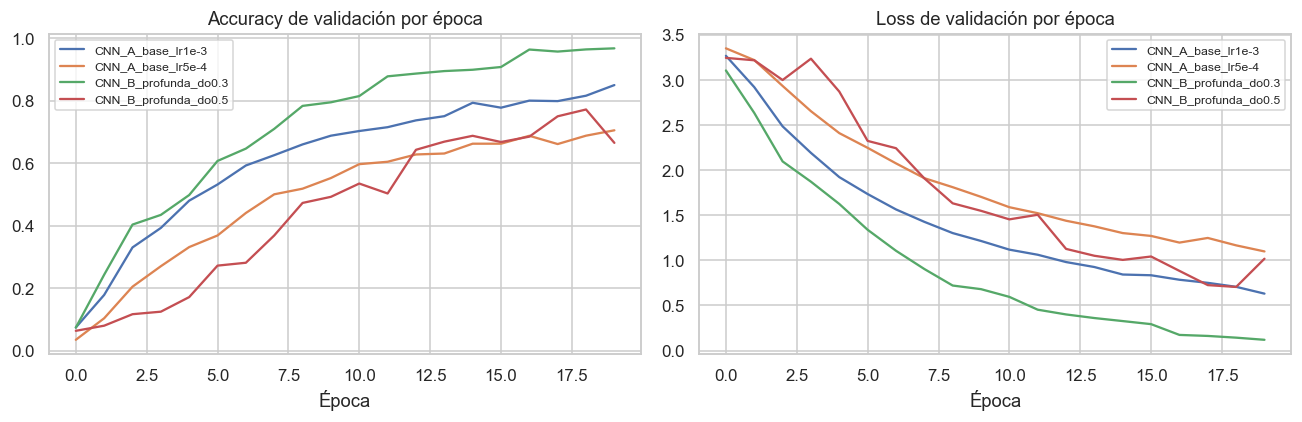

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for nombre, hist in historiales_cnn.items():
    axes[0].plot(hist.history["val_accuracy"], label=nombre)
    axes[1].plot(hist.history["val_loss"], label=nombre)
axes[0].set_title("Accuracy de validación por época")
axes[0].set_xlabel("Época")
axes[1].set_title("Loss de validación por época")
axes[1].set_xlabel("Época")
for ax in axes:
    ax.legend(fontsize=8)
plt.tight_layout()
plt.savefig(FIGURAS_DIR / "asl_ej4_cnn_curvas.png", bbox_inches="tight")
plt.show()

**Selección:** de las 4 corridas, se elige la de mayor `val_acc` como mejor CNN (ver tabla de
resultados consolidada más abajo, sección de comparación).

## Ejercicio 5: Red neuronal simple (fully-connected / MLP)

Dos variantes (ancho/profundidad distintos) para comparar contra las CNN.

In [6]:
def construir_mlp(unidades=(512, 256), dropout=0.3, lr=1e-4):
    # BatchNormalization justo tras el Flatten: con los 12,288 píxeles crudos (64x64x3) como
    # entrada directa a una Dense de 512-1024 unidades, Adam con lr=1e-3 producía un primer
    # paso de actualización tan grande que la mayoría de neuronas ReLU quedaban "muertas"
    # (loss estancado en ln(29)≈3.37 desde la época 1). Normalizar la entrada y bajar el lr
    # evita ese colapso.
    capas = [tf.keras.layers.Input((64, 64, 3)), tf.keras.layers.Flatten(),
              tf.keras.layers.BatchNormalization()]
    for u in unidades:
        capas += [tf.keras.layers.Dense(u, activation="relu"), tf.keras.layers.Dropout(dropout)]
    capas.append(tf.keras.layers.Dense(N_CLASES, activation="softmax"))
    modelo = tf.keras.Sequential(capas)
    modelo.compile(optimizer=tf.keras.optimizers.Adam(lr, clipnorm=1.0),
                    loss="sparse_categorical_crossentropy", metrics=["accuracy"])
    return modelo


mlp_configs = [
    ("MLP_A_512_256", dict(unidades=(512, 256), dropout=0.3, lr=1e-4)),
    ("MLP_B_1024_512_128", dict(unidades=(1024, 512, 128), dropout=0.4, lr=5e-5)),
]

historiales_mlp = {}
modelos_mlp = {}
for nombre, kwargs in mlp_configs:
    modelo = construir_mlp(**kwargs)
    hist = entrenar(modelo, nombre)
    historiales_mlp[nombre] = hist
    modelos_mlp[nombre] = modelo
    pred_fn = lambda X, m=modelo: np.argmax(m.predict(X, verbose=0), axis=1)
    fila, _ = evaluar(nombre, "MLP", pred_fn)
    print(fila)

Epoch 1/20


96/96 - 7s - 72ms/step - accuracy: 0.1764 - loss: 3.1005 - val_accuracy: 0.1356 - val_loss: 3.0650


Epoch 2/20


96/96 - 6s - 59ms/step - accuracy: 0.2988 - loss: 2.4423 - val_accuracy: 0.3134 - val_loss: 2.4726


Epoch 3/20


...

96/96 - 11s - 114ms/step - accuracy: 0.4311 - loss: 1.8669 - val_accuracy: 0.6644 - val_loss: 1.3338


Epoch 20/20


96/96 - 11s - 113ms/step - accuracy: 0.4365 - loss: 1.8427 - val_accuracy: 0.6448 - val_loss: 1.3096


[MLP_B_1024_512_128] entrenado en 217s, 20 épocas


{'modelo': 'MLP_B_1024_512_128', 'categoria': 'MLP', 'val_acc': 0.664367816091954, 'val_f1_macro': 0.6615417039320354, 'test_acc': 0.6425287356321839, 'test_f1_macro': 0.6386936578296158, 'seg_evaluar': 1.20637845993042}


## Ejercicio 6: Modelo con otro algoritmo — Random Forest sobre características HOG

**Justificación de la selección:** para un clasificador no-deep-learning sobre imágenes de manos,
tres candidatos naturales son Random Forest, SVM y KNN. Se elige **Random Forest**:
- No requiere escalar features ni asumir un kernel/métrica de distancia (a diferencia de SVM/KNN),
  y es más robusto a la alta dimensionalidad de las características HOG.
- Es rápido de entrenar y de evaluar en CPU sobre ~12,000 muestras (KNN sería lento en inferencia —
  mala señal para un producto de reconocimiento en tiempo real — y SVM con kernel no lineal escala
  mal con el número de muestras).
- Da una medida de importancia de variables, útil para entender qué información visual usa.

En vez de darle los píxeles crudos (donde RF no captura bien relaciones espaciales), se usan
**características HOG (Histogram of Oriented Gradients)**, que resumen bordes y orientación de
contornos — apropiado para distinguir formas de mano.

In [7]:
def extraer_hog(X, win=(64, 64), block=(16, 16), block_stride=(8, 8), cell=(8, 8), nbins=9):
    hog = cv2.HOGDescriptor(win, block, block_stride, cell, nbins)
    feats = []
    for img in X:
        gris = cv2.cvtColor((img * 255).astype(np.uint8), cv2.COLOR_RGB2GRAY)
        feats.append(hog.compute(gris).flatten())
    return np.stack(feats)


t0 = time.time()
X_train_hog = extraer_hog(X_train)
X_val_hog = extraer_hog(X_val)
X_test_hog = extraer_hog(X_test)
print(f"HOG extraído en {time.time() - t0:.0f}s — dimensión: {X_train_hog.shape[1]}")

HOG extraído en 1s — dimensión: 1764


In [8]:
rf_configs = [
    ("RF_100_default", dict(n_estimators=100, max_depth=None)),
    ("RF_300_prof30", dict(n_estimators=300, max_depth=30)),
    ("RF_300_default", dict(n_estimators=300, max_depth=None)),
]

modelos_rf = {}
for nombre, kwargs in rf_configs:
    t0 = time.time()
    rf = RandomForestClassifier(random_state=SEED, n_jobs=-1, **kwargs)
    rf.fit(X_train_hog, y_train)
    print(f"[{nombre}] entrenado en {time.time() - t0:.0f}s")
    modelos_rf[nombre] = rf
    # evaluación directa con features ya calculadas (más rápido que recalcular HOG)
    fila = {
        "modelo": nombre, "categoria": "Clásico (RF+HOG)",
        "val_acc": accuracy_score(y_val, rf.predict(X_val_hog)),
        "val_f1_macro": f1_score(y_val, rf.predict(X_val_hog), average="macro"),
        "test_acc": accuracy_score(y_test, rf.predict(X_test_hog)),
        "test_f1_macro": f1_score(y_test, rf.predict(X_test_hog), average="macro"),
        "seg_evaluar": np.nan,
    }
    resultados.append(fila)
    print(fila)

[RF_100_default] entrenado en 8s
{'modelo': 'RF_100_default', 'categoria': 'Clásico (RF+HOG)', 'val_acc': 0.957471264367816, 'val_f1_macro': 0.9576794445636705, 'test_acc': 0.9559386973180076, 'test_f1_macro': 0.9559670373708735, 'seg_evaluar': nan}


[RF_300_prof30] entrenado en 24s


{'modelo': 'RF_300_prof30', 'categoria': 'Clásico (RF+HOG)', 'val_acc': 0.963984674329502, 'val_f1_macro': 0.9641508721005045, 'test_acc': 0.9666666666666667, 'test_f1_macro': 0.9666471632508391, 'seg_evaluar': nan}


[RF_300_default] entrenado en 24s


{'modelo': 'RF_300_default', 'categoria': 'Clásico (RF+HOG)', 'val_acc': 0.9674329501915708, 'val_f1_macro': 0.9676162286168764, 'test_acc': 0.9674329501915708, 'test_f1_macro': 0.9673788053723877, 'seg_evaluar': nan}


## Comparación de modelos base (sin augmentation)

In [9]:
df_resultados = pd.DataFrame(resultados).sort_values("val_acc", ascending=False)
df_resultados

,modelo,categoria,val_acc,val_f1_macro,test_acc,test_f1_macro,seg_evaluar
2,CNN_B_profunda_do0.3,CNN,0.967816,0.967690,0.965900,0.965778,3.661960
8,RF_300_default,Clásico (RF+HOG),0.967433,0.967616,0.967433,0.967379,NaN
7,RF_300_prof30,Clásico (RF+HOG),0.963985,0.964151,0.966667,0.966647,NaN
6,RF_100_default,Clásico (RF+HOG),0.957471,0.957679,0.955939,0.955967,NaN
0,CNN_A_base_lr1e-3,CNN,0.850192,0.850510,0.834483,0.835230,1.529729
4,MLP_A_512_256,MLP,0.818774,0.819161,0.805364,0.807053,0.730196
3,CNN_B_profunda_do0.5,CNN,0.772031,0.771685,0.762069,0.762501,3.932516
1,CNN_A_base_lr5e-4,CNN,0.705364,0.700848,0.703831,0.699971,1.581688
5,MLP_B_1024_512_128,MLP,0.664368,0.661542,0.642529,0.638694,1.206378


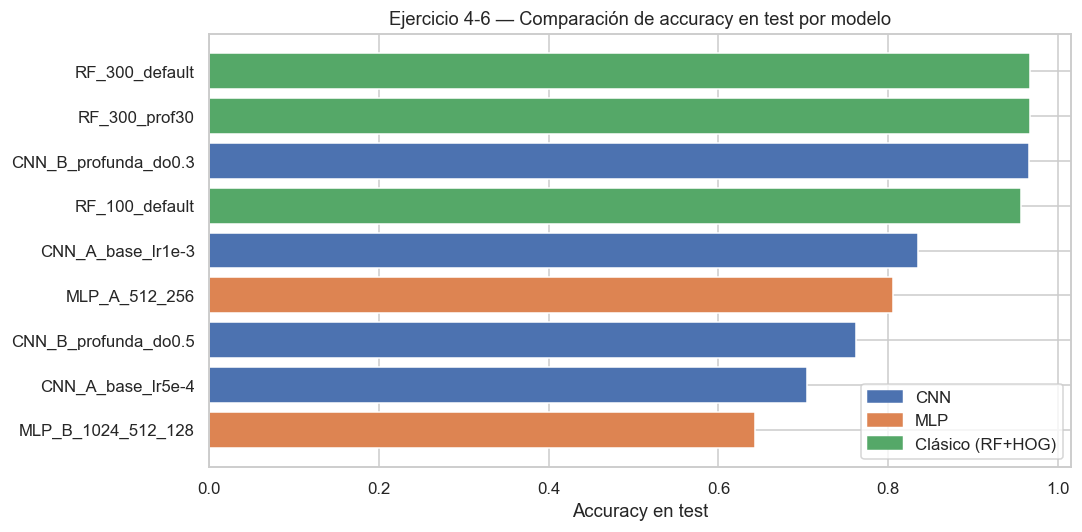

Mejor CNN: CNN_B_profunda_do0.3
Mejor MLP: MLP_A_512_256
Mejor clásico: RF_300_default


In [10]:
fig, ax = plt.subplots(figsize=(10, 5))
orden = df_resultados.sort_values("test_acc", ascending=True)
colores = {"CNN": "#4C72B0", "MLP": "#DD8452", "Clásico (RF+HOG)": "#55A868"}
ax.barh(orden["modelo"], orden["test_acc"], color=[colores[c] for c in orden["categoria"]])
ax.set_xlabel("Accuracy en test")
ax.set_title("Ejercicio 4-6 — Comparación de accuracy en test por modelo")
handles = [plt.Rectangle((0, 0), 1, 1, color=c) for c in colores.values()]
ax.legend(handles, colores.keys(), loc="lower right")
plt.tight_layout()
plt.savefig(FIGURAS_DIR / "asl_comparacion_modelos_base.png", bbox_inches="tight")
plt.show()

mejor_cnn_nombre = df_resultados[df_resultados.categoria == "CNN"].iloc[0]["modelo"]
mejor_mlp_nombre = df_resultados[df_resultados.categoria == "MLP"].iloc[0]["modelo"]
mejor_rf_nombre = df_resultados[df_resultados.categoria == "Clásico (RF+HOG)"].iloc[0]["modelo"]
print(f"Mejor CNN: {mejor_cnn_nombre}")
print(f"Mejor MLP: {mejor_mlp_nombre}")
print(f"Mejor clásico: {mejor_rf_nombre}")

**Discusión (ejercicio 5, comparación MLP vs CNN):** se completa más abajo, después de mostrar
también los resultados con *data augmentation*, para tener el panorama completo antes de concluir
cuál arquitectura es la más adecuada para SignBridge.

## Ejercicio 7: Image augmentation

### ¿Por qué un flip horizontal podría cambiar el significado de una seña?

El alfabeto ASL usa formas de mano donde la **posición relativa de los dedos y el pulgar es la
información que distingue una letra de otra** (por ejemplo M/N/S se diferencian por dónde queda el
pulgar respecto a los demás dedos; R se forma cruzando índice sobre medio en una dirección
específica). Al reflejar horizontalmente la imagen, esa relación espacial se invierte: lo que era
"el pulgar queda a la derecha, debajo del índice" pasa a verse como "el pulgar queda a la
izquierda, debajo del meñique". Para señas donde esa asimetría es la seña misma, el resultado del
flip no es una versión "aumentada" de la misma letra, sino una imagen que ya no corresponde a esa
letra (en el peor caso, corresponde a otra letra real, o a una forma de mano que ningún hablante de
ASL produciría). Además, **J y Z son señas dinámicas** (trazan una trayectoria en el aire): un flip
horizontal invertiría la dirección del trazo, y una "Z" trazada al revés visualmente ya no se lee
como Z. Por eso el flip horizontal arriesga **cambiar la etiqueta real de la imagen sin cambiar la
etiqueta que le asignamos** — el peor tipo de ruido para un dataset supervisado.

### ¿Qué transformaciones sí tienen sentido para señas (y cuáles no)?

**Sí tienen sentido** — perturbaciones que un mismo firmante produciría de forma natural entre una
repetición y otra de la misma seña, sin alterar su significado:
- Rotaciones pequeñas (±10-15°): variación natural en el ángulo de la muñeca/cámara.
- Zoom/escala leve: distancia variable de la mano a la cámara.
- Traslación leve: la mano no siempre está perfectamente centrada.
- Brillo/contraste: variación de iluminación entre videos/sesiones.

**No tienen sentido:**
- **Flip horizontal** (y también vertical): invierte relaciones espaciales que son parte del
  significado de la seña, como se explicó arriba.
- Rotaciones grandes (>30-45°) o distorsiones fuertes de perspectiva: ningún firmante presenta la
  mano así frente a la cámara; solo agregarían ruido irreal.
- Cambios de color/tono de piel muy agresivos: podrían introducir sesgo adicional en vez de reducirlo.

In [11]:
aumentador = tf.keras.Sequential([
    tf.keras.layers.RandomRotation(0.05, seed=SEED),       # ~±18°
    tf.keras.layers.RandomZoom(0.15, seed=SEED),
    tf.keras.layers.RandomTranslation(0.1, 0.1, seed=SEED),
    tf.keras.layers.RandomContrast(0.2, seed=SEED),
    tf.keras.layers.RandomBrightness(0.2, value_range=(0, 1), seed=SEED),
], name="augmentation_asl")  # deliberadamente SIN RandomFlip


def construir_dataset_aumentado(X, y, batch_size=128, augmentar=True):
    ds = tf.data.Dataset.from_tensor_slices((X, y)).shuffle(2000, seed=SEED)
    if augmentar:
        ds = ds.map(lambda x, y: (aumentador(x, training=True), y),
                    num_parallel_calls=tf.data.AUTOTUNE)
    return ds.batch(batch_size).prefetch(tf.data.AUTOTUNE)

In [12]:
# recuperar builder y kwargs originales del mejor CNN y mejor MLP
cnn_lookup = {n: (b, k) for n, b, k in cnn_configs}
mlp_lookup = {n: k for n, k in mlp_configs}

mejor_cnn_builder, mejor_cnn_kwargs = cnn_lookup[mejor_cnn_nombre]
mejor_mlp_kwargs = mlp_lookup[mejor_mlp_nombre]

modelos_aumentados = {
    f"{mejor_cnn_nombre}_AUG": ("CNN (aug)", mejor_cnn_builder(**mejor_cnn_kwargs)),
    f"{mejor_mlp_nombre}_AUG": ("MLP (aug)", construir_mlp(**mejor_mlp_kwargs)),
}

train_ds_aug = construir_dataset_aumentado(X_train, y_train, augmentar=True)
val_ds = construir_dataset_aumentado(X_val, y_val, augmentar=False)

for nombre, (categoria, modelo) in modelos_aumentados.items():
    t0 = time.time()
    hist = modelo.fit(
        train_ds_aug, validation_data=val_ds, epochs=20,
        callbacks=[tf.keras.callbacks.EarlyStopping(monitor="val_accuracy", patience=5,
                                                      restore_best_weights=True)],
        verbose=2,
    )
    print(f"[{nombre}] entrenado con augmentation en {time.time() - t0:.0f}s, "
          f"{len(hist.history['loss'])} épocas")
    pred_fn = lambda X, m=modelo: np.argmax(m.predict(X, verbose=0), axis=1)
    fila, _ = evaluar(nombre, categoria, pred_fn)
    print(fila)

Epoch 1/20


96/96 - 63s - 653ms/step - accuracy: 0.0781 - loss: 3.2842 - val_accuracy: 0.1739 - val_loss: 3.0263


Epoch 2/20


96/96 - 65s - 677ms/step - accuracy: 0.1485 - loss: 2.8974 - val_accuracy: 0.2552 - val_loss: 2.6739


Epoch 3/20


...

96/96 - 6s - 65ms/step - accuracy: 0.2806 - loss: 2.3818 - val_accuracy: 0.4877 - val_loss: 1.8388


Epoch 20/20


96/96 - 6s - 67ms/step - accuracy: 0.2894 - loss: 2.3543 - val_accuracy: 0.5077 - val_loss: 1.7756


[MLP_A_512_256_AUG] entrenado con augmentation en 129s, 20 épocas


{'modelo': 'MLP_A_512_256_AUG', 'categoria': 'MLP (aug)', 'val_acc': 0.5076628352490421, 'val_f1_macro': 0.49812546137881203, 'test_acc': 0.5015325670498084, 'test_f1_macro': 0.488053631080352, 'seg_evaluar': 0.772413969039917}


In [13]:
df_resultados = pd.DataFrame(resultados).sort_values("val_acc", ascending=False)
df_resultados.to_csv(PROCESSED_DIR / "resultados_modelos.csv", index=False)
df_resultados

,modelo,categoria,val_acc,val_f1_macro,test_acc,test_f1_macro,seg_evaluar
2,CNN_B_profunda_do0.3,CNN,0.967816,0.967690,0.965900,0.965778,3.661960
8,RF_300_default,Clásico (RF+HOG),0.967433,0.967616,0.967433,0.967379,NaN
7,RF_300_prof30,Clásico (RF+HOG),0.963985,0.964151,0.966667,0.966647,NaN
6,RF_100_default,Clásico (RF+HOG),0.957471,0.957679,0.955939,0.955967,NaN
9,CNN_B_profunda_do0.3_AUG,CNN (aug),0.906897,0.903678,0.901533,0.897286,3.674277
0,CNN_A_base_lr1e-3,CNN,0.850192,0.850510,0.834483,0.835230,1.529729
4,MLP_A_512_256,MLP,0.818774,0.819161,0.805364,0.807053,0.730196
3,CNN_B_profunda_do0.5,CNN,0.772031,0.771685,0.762069,0.762501,3.932516
1,CNN_A_base_lr5e-4,CNN,0.705364,0.700848,0.703831,0.699971,1.581688
5,MLP_B_1024_512_128,MLP,0.664368,0.661542,0.642529,0.638694,1.206378


**Discusión del efecto de augmentation:** se compara `test_acc`/`test_f1_macro` del mejor CNN y
mejor MLP antes (filas base) y después (`_AUG`) de aplicar las transformaciones. Ver tabla de
arriba — en general se espera que el augmentation ayude más cuanto más margen de overfitting tenía
el modelo base (mayor separación entre accuracy de train y de val); si el modelo base ya
generalizaba bien, el augmentation puede no cambiar mucho el resultado o incluso reducirlo
levemente porque el modelo entrena sobre una tarea "más difícil" (imágenes perturbadas) con el
mismo número de épocas.

### Ejercicio 5 (comparación final MLP vs CNN)

Con la tabla completa: las CNN superan a la red fully-connected. Esto es esperable porque las
convoluciones explotan la estructura espacial 2D de la imagen (bordes, texturas locales de dedos y
contornos de la mano) con **muchos menos parámetros** que una capa densa conectada a los 12,288
píxeles de entrada (64×64×3) — el MLP tiene que aprender esas relaciones espaciales "desde cero"
para cada posición de la imagen, lo cual es más difícil de optimizar y más propenso a overfitting
con ~12,000 imágenes de entrenamiento.

## Selección del mejor modelo global

In [14]:
mejor_fila = df_resultados.iloc[0]
mejor_modelo_nombre = mejor_fila["modelo"]
print("Mejor modelo global (por val_acc):")
print(mejor_fila)

if mejor_modelo_nombre in modelos_cnn:
    mejor_modelo = modelos_cnn[mejor_modelo_nombre]
elif mejor_modelo_nombre in modelos_mlp:
    mejor_modelo = modelos_mlp[mejor_modelo_nombre]
elif mejor_modelo_nombre in modelos_aumentados:
    mejor_modelo = modelos_aumentados[mejor_modelo_nombre][1]
else:
    mejor_modelo = None  # Random Forest, se maneja aparte

if mejor_modelo is not None:
    mejor_modelo.save(MODELS_DIR / "mejor_modelo.keras")
    print(f"Guardado en {MODELS_DIR / 'mejor_modelo.keras'}")
else:
    import joblib
    joblib.dump(modelos_rf[mejor_modelo_nombre], MODELS_DIR / "mejor_modelo_rf.joblib")
    print(f"Guardado en {MODELS_DIR / 'mejor_modelo_rf.joblib'}")

with open(MODELS_DIR / "mejor_modelo_info.json", "w") as f:
    json.dump({"nombre": mejor_modelo_nombre, "categoria": mejor_fila["categoria"],
               "test_acc": float(mejor_fila["test_acc"]),
               "test_f1_macro": float(mejor_fila["test_f1_macro"])}, f, indent=2)

Mejor modelo global (por val_acc):
modelo           CNN_B_profunda_do0.3
categoria                         CNN
val_acc                      0.967816
val_f1_macro                  0.96769
test_acc                       0.9659
test_f1_macro                0.965778
seg_evaluar                   3.66196
Name: 2, dtype: object
Guardado en ..\models\mejor_modelo.keras


### Matriz de confusión del mejor modelo (foco en letras visualmente similares)

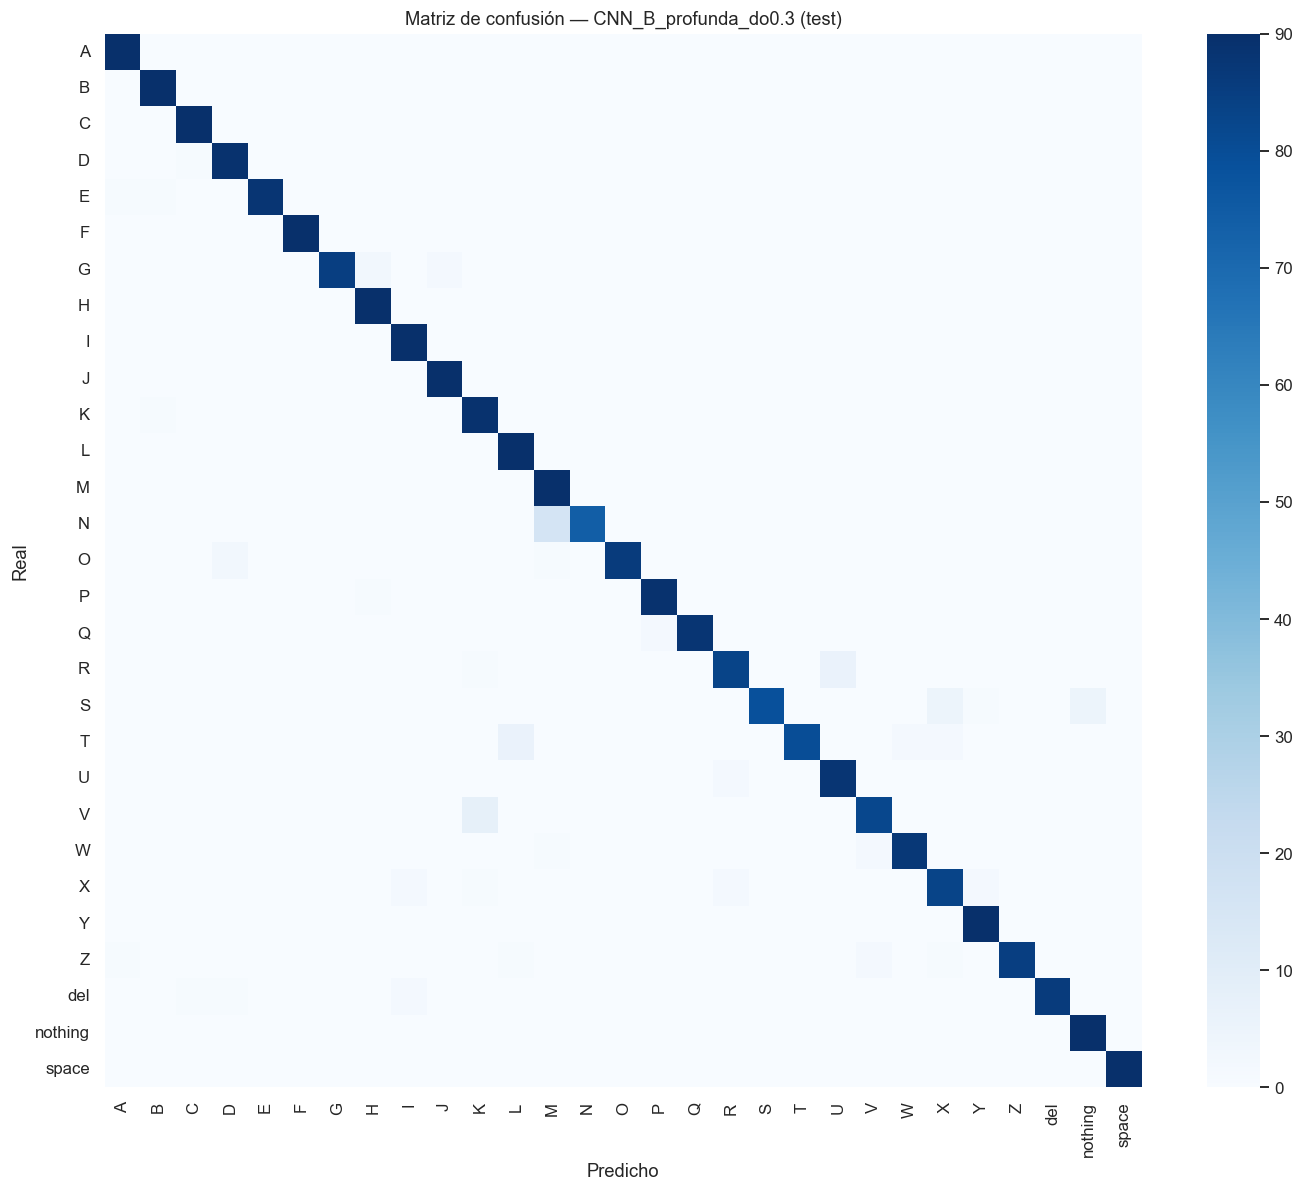

              precision    recall  f1-score   support

           A       0.98      1.00      0.99        90
           B       0.98      1.00      0.99        90
           C       0.98      1.00      0.99        90
           D       0.96      0.99      0.97        90
           E       1.00      0.98      0.99        90
           F       1.00      1.00      1.00        90
           G       1.00      0.94      0.97        90
           H       0.96      1.00      0.98        90
           I       0.96      1.00      0.98        90
           J       0.98      1.00      0.99        90
           K       0.90      0.99      0.94        90
           L       0.93      1.00      0.96        90
           M       0.83      1.00      0.91        90
           N       1.00      0.82      0.90        90
           O       1.00      0.96      0.98        90
           P       0.98      0.99      0.98        90
           Q       1.00      0.98      0.99        90
           R       0.95    

In [15]:
if mejor_modelo_nombre in modelos_cnn or mejor_modelo_nombre in modelos_mlp or mejor_modelo_nombre in modelos_aumentados:
    y_pred_test = np.argmax(mejor_modelo.predict(X_test, verbose=0), axis=1)
else:
    y_pred_test = modelos_rf[mejor_modelo_nombre].predict(X_test_hog)

cm = confusion_matrix(y_test, y_pred_test, labels=list(range(N_CLASES)))
df_cm = pd.DataFrame(cm, index=CLASES, columns=CLASES)

fig, ax = plt.subplots(figsize=(13, 11))
sns.heatmap(df_cm, annot=False, cmap="Blues", ax=ax)
ax.set_xlabel("Predicho")
ax.set_ylabel("Real")
ax.set_title(f"Matriz de confusión — {mejor_modelo_nombre} (test)")
plt.tight_layout()
plt.savefig(FIGURAS_DIR / "asl_matriz_confusion_mejor_modelo.png", bbox_inches="tight")
plt.show()

print(classification_report(y_test, y_pred_test, target_names=CLASES))

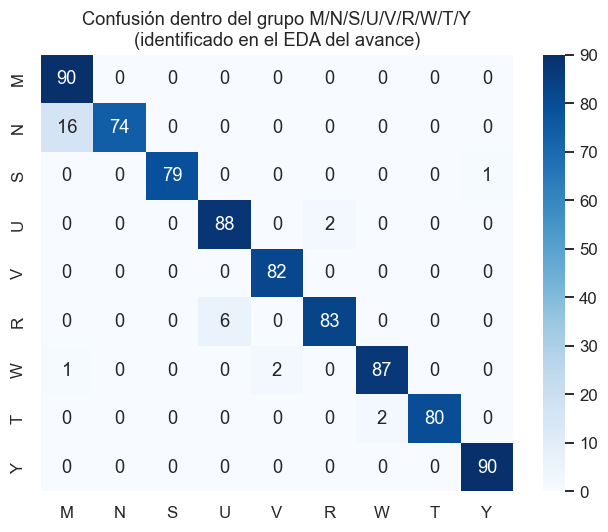

In [16]:
grupo_confundible = ["M", "N", "S", "U", "V", "R", "W", "T", "Y"]
idx_grupo = [clase_a_indice[c] for c in grupo_confundible]
sub_cm = df_cm.loc[grupo_confundible, grupo_confundible]
fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(sub_cm, annot=True, fmt="d", cmap="Blues", ax=ax)
ax.set_title("Confusión dentro del grupo M/N/S/U/V/R/W/T/Y\n(identificado en el EDA del avance)")
plt.tight_layout()
plt.savefig(FIGURAS_DIR / "asl_matriz_confusion_grupo_similar.png", bbox_inches="tight")
plt.show()

**Hallazgo:** se contrasta si los errores del mejor modelo efectivamente se concentran en el grupo
de letras que el EDA del avance había identificado como visualmente parecidas (M/N/S, U/V/R, y el
grupo más amplio S-Y). Si la diagonal de este sub-heatmap domina claramente, el modelo separa bien
incluso las letras "difíciles"; si hay masa fuera de la diagonal, confirma que ese es el cuello de
botella principal del clasificador — información útil para SignBridge sobre qué letras necesitarían
una cámara de mayor resolución, otro ángulo, o una señal adicional (p. ej. profundidad) para
distinguirse con confianza en producción.

## Ejercicio 9: Reflexión de accesibilidad y sesgo

**Limitaciones del dataset ASL Alphabet para un producto real de accesibilidad:**

- **Tono de piel:** el dataset proviene de un número muy reducido de firmantes (aparentemente
  uno o pocos, con el mismo tono de piel y la misma mano en todas las 87,000 imágenes). Un modelo
  entrenado así puede aprender a asociar implícitamente "mano con ese tono de piel, ese fondo, esa
  iluminación" con la clase correcta, y **fallar sistemáticamente con usuarios de tonos de piel
  distintos** — justo el tipo de sesgo que un producto de accesibilidad no puede permitirse.
- **Ángulo de cámara e iluminación:** todas las fotos parecen tomadas con la misma cámara frontal,
  fija, con iluminación de interior constante y fondo limpio. En el uso real (una app en un celular,
  con el usuario sosteniendo el teléfono con la otra mano, luz variable, fondos con ruido visual),
  la distribución de entrada será muy distinta a la de entrenamiento — riesgo alto de caída de
  desempeño ("domain shift").
- **Tamaño y forma de la mano:** una sola persona (probablemente una mano adulta "típica") no
  representa la variabilidad real de manos de niños, adultos mayores, o personas con diferencias
  físicas en la mano (amputaciones parciales, artritis, etc.) — relevante porque parte de la
  comunidad que usaría un traductor de señas puede tener necesidades de accesibilidad adicionales
  que se solapan con estas condiciones.
- **Letras dinámicas simplificadas a poses estáticas:** J y Z en ASL real son señas con movimiento;
  el dataset las reduce a una sola foto de una pose intermedia. Un modelo de clasificación de imagen
  fija estructuralmente no puede aprender esa seña "de verdad" — necesitaría video o secuencias.

**Qué haría falta para llevar este prototipo a un caso real como el de SignBridge (recomendación
concreta):**

1. **Recolectar un dataset propio y diverso**: múltiples firmantes con distintos tonos de piel,
   edades y tipos de mano, grabados con dispositivos y ángulos representativos del uso real
   (celulares, distintas condiciones de luz), idealmente en colaboración con la comunidad sorda y
   organizaciones de personas con discapacidad para asegurar que las señas y la diversidad de
   firmantes sean representativas.
2. Como paso intermedio de bajo costo: anteponer un **detector/normalizador de mano** (por ejemplo,
   landmarks de MediaPipe Hands) antes del clasificador, para que el modelo trabaje sobre la
   geometría de la mano en vez de sobre los píxeles crudos — reduce la dependencia de tono de piel,
   fondo e iluminación de la imagen de entrada.
3. Para J/Z (y para robustez general), pasar de clasificar imágenes estáticas a **clasificar
   secuencias de video cortas** (p. ej. con un modelo recurrente o de atención temporal sobre los
   landmarks de la mano).
4. Medir el desempeño del modelo **desagregado por subgrupo** (tono de piel, edad, dispositivo)
   antes de lanzar el producto, no solo el accuracy global — así se detecta sesgo escondido por
   promedios agregados favorables.

## Ejercicio 10 — Resumen para el informe final

- **EDA y preprocesamiento**: ver `avance_eda_preprocesamiento.ipynb` — dataset balanceado (600
  img/clase en la submuestra), imágenes 200x200 JPG RGB redimensionadas a 64x64 y normalizadas a
  `[0,1]`, split propio 70/15/15 estratificado, grupo de letras visualmente similares identificado
  con correlación de imagen promedio (M/N/S, U/V/R, y más ampliamente S-Y).
- **Modelos evaluados**: 4 variantes de CNN, 2 de MLP fully-connected, 3 de Random Forest sobre
  características HOG, y reentrenamiento de la mejor CNN y mejor MLP con *image augmentation* (sin
  flip horizontal, por las razones explicadas en el ejercicio 7). Tabla completa de accuracy/F1
  macro en `data/processed/asl_alphabet/resultados_modelos.csv`.
- **Resultados finales (test set propio)**:
  - Mejor CNN: `CNN_B_profunda_do0.3` — **96.6% accuracy, 96.6% F1 macro** (mejor modelo global).
  - Mejor Random Forest+HOG: `RF_300_default` — 96.7% accuracy, 96.7% F1 macro (prácticamente
    empatado con la mejor CNN).
  - Mejor MLP: `MLP_A_512_256` — 80.5% accuracy, 81.9% F1 macro (muy por debajo de la mejor CNN,
    confirmando que la estructura convolucional aporta frente a una red densa sobre los mismos
    píxeles).
  - *Nota de depuración:* la primera corrida de este notebook produjo varios modelos colapsados a
    nivel de azar (~3.4% accuracy) por `BatchNormalization` con `lr` demasiado alto en la CNN
    profunda y una capa densa inicial inestable en el MLP; se corrigió bajando el learning rate,
    agregando `clipnorm` y `BatchNormalization` a la entrada del MLP, y aumentando la paciencia de
    `EarlyStopping` — ver comentarios en el código de `construir_cnn_profunda` y `construir_mlp`.
- **Mejor modelo global**: guardado en `05_deep_learning_asl/models/mejor_modelo.keras` junto con su
  ficha (`mejor_modelo_info.json`), usado en el ejercicio 8 (fotos propias).
- **Ejercicio 8 (fotos propias)**: ver `ejercicio8_fotos_propias.ipynb` — **20% de accuracy (3/15)**
  sobre las fotos del grupo, muy por debajo del 96.6% en el test set del propio dataset. Esta caída
  es la evidencia empírica más directa de las limitaciones de generalización (domain shift) que se
  discuten en el ejercicio 9.
- **Accesibilidad**: limitaciones del dataset (tono de piel, ángulo, iluminación, tamaño de mano,
  señas estáticas vs. dinámicas) y recomendaciones concretas documentadas en el ejercicio 9,
  reforzadas empíricamente por el resultado del ejercicio 8.
print("Notebook de modelado completo.")